# **Introduction**

Hundreds of thousands of recipes exist around the world, and here we are going to explore the underlying relationships between them across different cuisines. Understanding these connections has many benefits:

*    A restaurateur looking to attract more customers can target ads to individuals who enjoy similar cuisines, making it more likely they will appreciate the restaurateur's dishes.

*    A thrifty epicurean can identify cuisines with common flavor profiles, allowing them to create a targeted grocery list that minimizes waste while enabling the preparation of a wide variety of dishes.

*    A diner stuck in a rut can seek out the most dissimilar cuisines to their usual fare and discover something new.

These are just a few examples of the insights recipes can provide.

In this notebook, we will:

*    Import, inspect, and clean the recipe data,

*    Use visualizations to deepen our understanding of the data,

*    Preprocess and further visualize the data to assess its readiness for modeling,

*   Apply unsupervised machine learning techniques to uncover hidden connections between cuisines,

*   Finally, evaluate how our methods could be improved.

# Imports

In [234]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import json
import seaborn as sns
import umap

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.decomposition import NMF, PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from scipy.stats import mode
from sklearn.metrics.pairwise import cosine_similarity

In [235]:
# Data Import
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading

**RECIPE DATA SET FROM KAGGLE**

In [236]:
recipe_data = pd.read_json('/content/drive/My Drive/Unsupervised Algorithms in Machine Learning/Week 5/train.json')

# Inspecting and Cleaning

**RECIPE DATA**

In [237]:
recipe_data.head()

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


In [238]:
recipe_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39774 entries, 0 to 39773
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           39774 non-null  int64 
 1   cuisine      39774 non-null  object
 2   ingredients  39774 non-null  object
dtypes: int64(1), object(2)
memory usage: 932.3+ KB


**UNIQUE CUISINES**

In [239]:
print(recipe_data['cuisine'].unique())

['greek' 'southern_us' 'filipino' 'indian' 'jamaican' 'spanish' 'italian'
 'mexican' 'chinese' 'british' 'thai' 'vietnamese' 'cajun_creole'
 'brazilian' 'french' 'japanese' 'irish' 'korean' 'moroccan' 'russian']


**INGREDIENT TYPE**

In [240]:
recipe_data['ingredients'].head()

,ingredients
0,"[romaine lettuce, black olives, grape tomatoes..."
1,"[plain flour, ground pepper, salt, tomatoes, g..."
2,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,"[water, vegetable oil, wheat, salt]"
4,"[black pepper, shallots, cornflour, cayenne pe..."


In [241]:
all_lists = recipe_data['ingredients'].apply(lambda x: isinstance(x, list)).all()

print(f"All ingredients are lists: {all_lists}")

All ingredients are lists: True


**ID UNIQUENESS**

In [242]:
# Check the uniqueness of each recipe and remove duplicates
duplicates = recipe_data.duplicated('id').sum()

recipe_data = recipe_data.drop_duplicates(subset='id')

print(f'{duplicates} Duplicates found and removed')

0 Duplicates found and removed


# Visualizing

* recipe breakdown by cuisine
* ingredient distribution

**RECIPE COUNTS BY CUISINE**

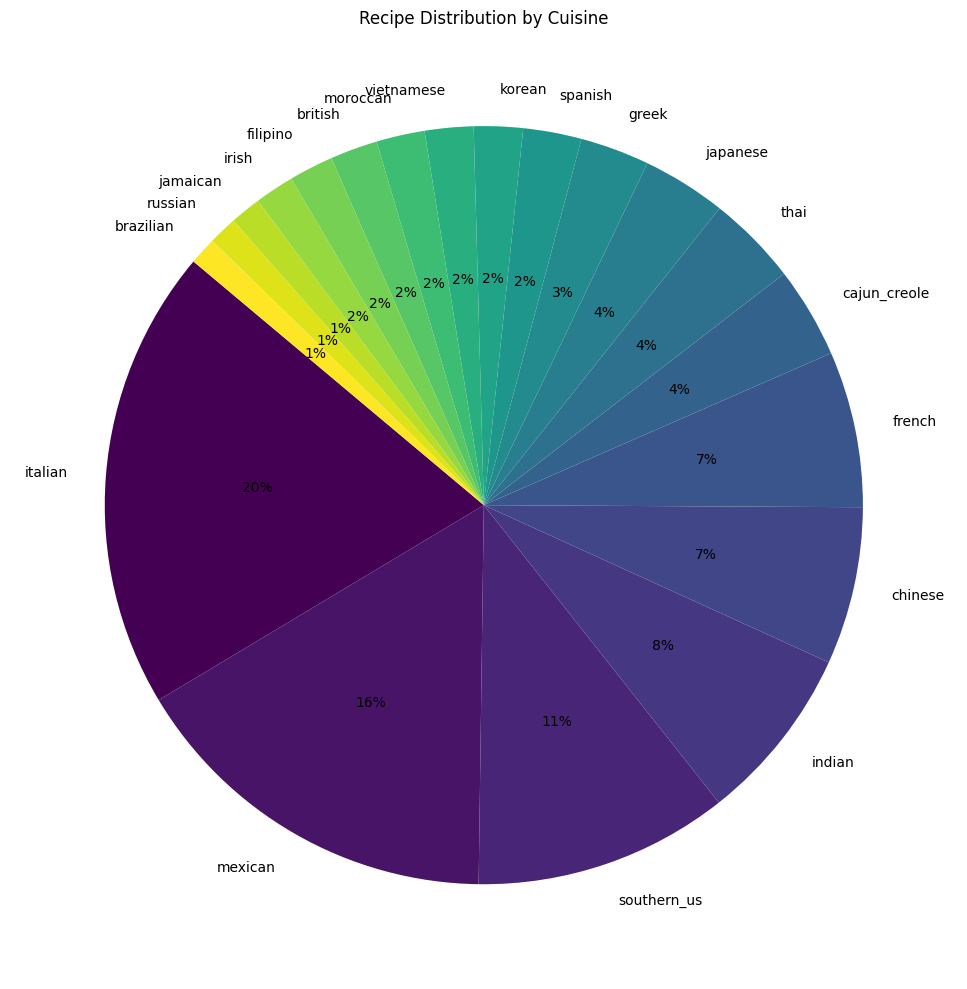

In [243]:
# Count occurrences of each cuisine
recipe_counts = recipe_data['cuisine'].value_counts()

cuisines = recipe_counts.index  # Categories
counts = recipe_counts.values   # Counts

# Create a pie chart
fig, ax = plt.subplots(figsize=(10, 10))

# Define colors
colors = plt.cm.viridis(np.linspace(0, 1, len(cuisines)))

# Create pie
wedges, texts, autotexts = ax.pie(
    counts,
    labels=cuisines,
    autopct='%1.f%%',  # Show percentages
    startangle=140,     # Rotate for better look
    colors=colors,
    textprops={'fontsize': 10}
)

# Title
ax.set_title('Recipe Distribution by Cuisine')

plt.tight_layout()
plt.show()

In [244]:
print(recipe_data['cuisine'].value_counts())

cuisine
italian         7838
mexican         6438
southern_us     4320
indian          3003
chinese         2673
french          2646
cajun_creole    1546
thai            1539
japanese        1423
greek           1175
spanish          989
korean           830
vietnamese       825
moroccan         821
british          804
filipino         755
irish            667
jamaican         526
russian          489
brazilian        467
Name: count, dtype: int64


**INGREDIENT COUNT**

In [245]:
recipe_data['ingredient_count'] = recipe_data['ingredients'].apply(len)

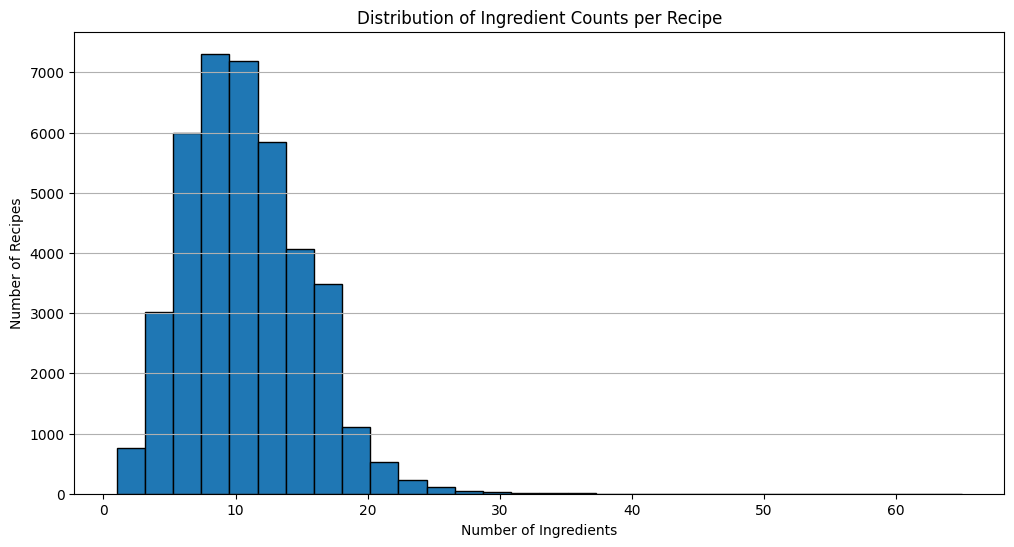

In [246]:
# Histogram of recipe ingredient counts
plt.figure(figsize=(12, 6))
plt.hist(recipe_data['ingredient_count'], bins=30, edgecolor='black')
plt.title('Distribution of Ingredient Counts per Recipe')
plt.xlabel('Number of Ingredients')
plt.ylabel('Number of Recipes')
plt.grid(axis='y')
plt.show()

Based on the visuals above, it looks like Italian ingredients may have an outsized impact on our data since roughly 20% of our recipes are Italian. We won't make any adjustments right now, but it's important to keep this in mind when reviewing our results. Most recipes have between 5 and 10 ingredients. If different cuisines use the same base ingredients with only small variations in herbs and spices, they'll end up being pretty similar. On the other hand, if the base ingredients are totally different, we'll see a much larger dissimilarity. These kinds of shifts might even reflect broader cultural differences.

# Preprocesssing

*   factorize cuisines
*   ingredients across cuisines
*   custom stop word list
*   vectorize the ingredients (unigrams)



**FACTORIZE CUISINES**

In [247]:
# Factorize
cuisine_labels, unique_cuisines = recipe_data['cuisine'].factorize()

# Assign cuisine IDs
recipe_data['cuisine_id'] = cuisine_labels

# Create a Series for mapping
cuisine_map = pd.Series(unique_cuisines, index=range(len(unique_cuisines)))

# Create a Series for inverted mapping
inverse_cuisine_map = pd.Series(cuisine_map.index, index=cuisine_map.values)

In [248]:
cuisine_map

,0
0,greek
1,southern_us
2,filipino
3,indian
4,jamaican
5,spanish
6,italian
7,mexican
8,chinese
9,british


**NUMBER OF INGREDIENTS**

In [249]:
# Make sure ingredients is exploded properly
exploded = recipe_data.explode('ingredients')

# Group by ingredient, count distinct cuisines
ingredient_cuisine_counts = exploded.groupby('ingredients')['cuisine'].nunique()

# Total number of unique cuisines
total_cuisines = recipe_data['cuisine'].nunique()

# Normalize: Fraction of cuisines per ingredient
ingredient_cuisine_frequency = ingredient_cuisine_counts / total_cuisines

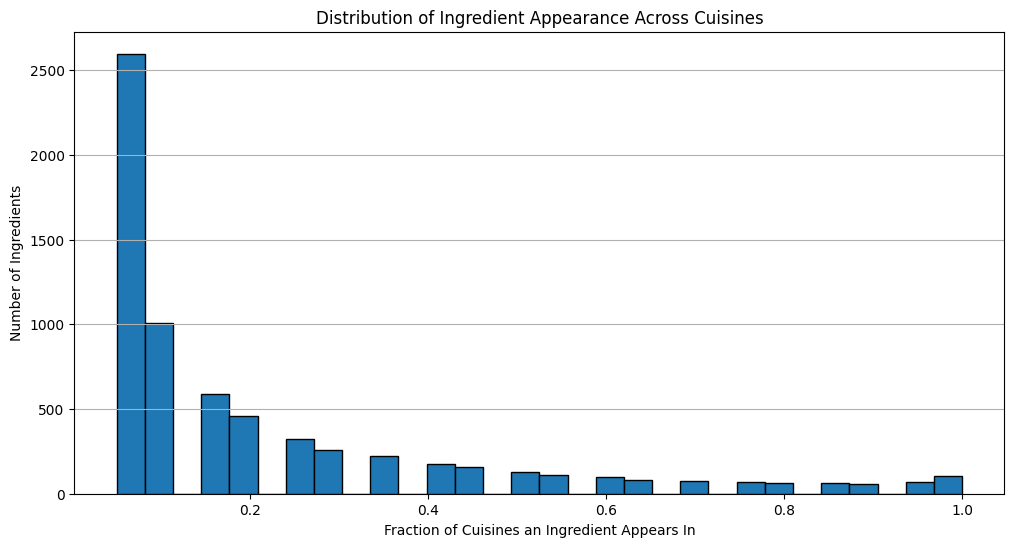

In [250]:
plt.figure(figsize=(12, 6))
plt.hist(ingredient_cuisine_frequency, bins=30, edgecolor='black')
plt.title('Distribution of Ingredient Appearance Across Cuisines')
plt.xlabel('Fraction of Cuisines an Ingredient Appears In')
plt.ylabel('Number of Ingredients')
plt.grid(axis='y')
plt.show()

**CUSTOM STOP WORDS, UNIVERSAL INGREDIENTS**

In [251]:
# Expand ingredients into a flat table
exploded = recipe_data.explode('ingredients')  # Each ingredient per row

# Group by ingredient and count number of distinct cuisines
ingredient_cuisine_counts = exploded.groupby('ingredients')['cuisine'].nunique()

# Normalize by total number of cuisines
total_cuisines = recipe_data['cuisine'].nunique()
ingredient_cuisine_frequency = ingredient_cuisine_counts / total_cuisines

# Filter: Ingredients used in more than 50% of cuisines
universal_ingredients = ingredient_cuisine_frequency[ingredient_cuisine_frequency > 0.5].index.tolist()

print(f"Universal Ingredients ({len(universal_ingredients)} total):")
print(universal_ingredients)

Universal Ingredients (797 total):
['1% low-fat milk', '2% reduced-fat milk', 'Italian parsley leaves', 'Sriracha', 'Tabasco Pepper Sauce', 'active dry yeast', 'agave nectar', 'all purpose unbleached flour', 'all-purpose flour', 'allspice', 'almond extract', 'almond flour', 'almonds', 'angel hair', 'anise', 'anise seed', 'apple cider vinegar', 'apple juice', 'apples', 'apricots', 'arugula', 'asparagus', 'asparagus spears', 'avocado', 'baby carrots', 'baby greens', 'baby spinach', 'baby spinach leaves', 'bacon', 'bacon slices', 'baguette', 'baking potatoes', 'baking powder', 'baking soda', 'balsamic vinegar', 'bamboo shoots', 'bananas', 'base', 'basil', 'basil leaves', 'basmati rice', 'bay leaf', 'bay leaves', 'beans', 'beaten eggs', 'beef', 'beef bouillon', 'beef brisket', 'beef broth', 'beef rib short', 'beef sirloin', 'beef stew meat', 'beef stock', 'beef tenderloin', 'beer', 'beets', 'bell pepper', 'berries', 'bibb lettuce', 'bittersweet chocolate', 'black beans', 'black pepper', 'b

In [252]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Convert to a list (or set) if you want
english_stop_words = list(ENGLISH_STOP_WORDS)

# Combine English stop words and universal ingredients
custom_stop_words = list(set(english_stop_words + universal_ingredients))

**VECTORIZE THE INGREDIENTS**

In [253]:
# Join each list of ingredients into a single string
recipe_data['ingredients_text'] = recipe_data['ingredients'].apply(lambda x: ' '.join(x))

In [254]:
# Vectorize
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    norm='l2',
    ngram_range=(1, 1),
    stop_words=custom_stop_words
)

recipe_vec = vectorizer.fit_transform(recipe_data['ingredients_text'])
print(recipe_vec.shape)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['active', 'adobo', 'agave', 'almond', 'angel', 'apple', 'apricot', 'baby', 'baking', 'balsamic', 'bamboo', 'basmati', 'bay', 'bean', 'beaten', 'bell', 'belly', 'bibb', 'bittersweet', 'black', 'blanched', 'boiled', 'boiling', 'bone', 'boneless', 'bones', 'bottled', 'bought', 'bouillon', 'breadcrumbs', 'breast', 'breasts', 'brisket', 'brown', 'brussels', 'bulb', 'buns', 'butt', 'butternut', 'button', 'cane', 'canned', 'caraway', 'cardamom', 'carrot', 'cashew', 'caster', 'chard', 'cheddar', 'cherry', 'chestnuts', 'chickens', 'chile', 'chilies', 'chipotles', 'chop', 'chopped', 'chops', 'chutney', 'cider', 'clam', 'cloves', 'club', 'coarse', 'cocoa', 'cold', 'coloring', 'colouring', 'condensed', 'confectioners', 'cooked', 'cooking', 'cracked', 'cranberries', 'cremini', 'crimini', 'crumb', 'crumbs

(39774, 2761)


**TOP INGREDIENTS FOR EACH CUISINE**

In [255]:
# Compute Chi-Square Scores for Each Cuisine Separately
# Top N n-grams per cuisine
N = 3

# Cuisine ID for each recipe
labels = recipe_data['cuisine_id'].values

# Vocabulary of ingredients
feature_names = vectorizer.get_feature_names_out()

# Store top ingredients
top_ngrams_per_cuisine = {}

for cuisine_id, cuisine_name in cuisine_map.items():

    # Create a binary target array: 1 if recipe is in this cuisine, 0 otherwise
    cuisine_mask = (labels == cuisine_id).astype(int)

    # Compute chi-square scores for THIS cuisine
    chi2_scores, _ = chi2(recipe_vec, cuisine_mask)

    # Get top N directly for this cuisine
    top_indices = np.argsort(chi2_scores)[-N:][::-1]
    cuisine_features = feature_names[top_indices]

    # Store the top N n-grams for this cuisine
    top_ngrams_per_cuisine[cuisine_name] = cuisine_features[:N]

# Display Results
for cuisine, ngrams in top_ngrams_per_cuisine.items():
    print(f'\nTop {N} ingredients for {cuisine}:')
    for rank, ngram in enumerate(ngrams, start=1):
        print(f"{rank}. {ngram}")


Top 3 ingredients for greek:
1. feta
2. crumbles
3. greek

Top 3 ingredients for southern_us:
1. grits
2. baking
3. collard

Top 3 ingredients for filipino:
1. calamansi
2. lumpia
3. belly

Top 3 ingredients for indian:
1. masala
2. garam
3. turmeric

Top 3 ingredients for jamaican:
1. jerk
2. jamaican
3. bonnet

Top 3 ingredients for spanish:
1. chorizo
2. spanish
3. manchego

Top 3 ingredients for italian:
1. parmesan
2. mozzarella
3. italian

Top 3 ingredients for mexican:
1. tortillas
2. jack
3. taco

Top 3 ingredients for chinese:
1. soy
2. chinese
3. sesame

Top 3 ingredients for british:
1. stilton
2. suet
3. mincemeat

Top 3 ingredients for thai:
1. thai
2. kaffir
3. galangal

Top 3 ingredients for vietnamese:
1. vietnamese
2. paper
3. vermicelli

Top 3 ingredients for cajun_creole:
1. cajun
2. creole
3. andouille

Top 3 ingredients for brazilian:
1. cachaca
2. açai
3. manioc

Top 3 ingredients for french:
1. yolks
2. gruyere
3. tarragon

Top 3 ingredients for japanese:
1. mir

The cuisines are factorized to give us a map between cuisine names and their corresponding IDs. When we look at the distribution of ingredients across cuisines, we notice a big spike near zero—these are rare ingredients. On the other end, more universal ingredients are clustered in the 0.7 to 1 range. To reduce noise, we create a custom stop word list by identifying these universal ingredients (those that appear in more than half the recipes) and combining them with the standard English stop words.

Next, we vectorize the ingredients using a TF-IDF vectorizer with this custom stop word list. Finally, we review the top three ingredients most strongly associated with each cuisine. Overall, the top ingredients seem to make sense and align well with their associated cuisines.

# PCA-UMAP Visualizing

*   ingredients most strongly correlated by cuisine



**CUSTOM COLOR PALETTE**

In [256]:
# Get list of cuisines
cuisines = list(cuisine_map.values)  # This will list your cuisine names

# Get distinct colors
palette = sns.color_palette('husl', n_colors=len(cuisines))

# Build cuisine → color dictionary
cuisine_color_dict = {cuisine: color for cuisine, color in zip(cuisines, palette)}

**DIMENSIONALITY REDUCTION**

In [257]:
# Create a random subset
random_subset = recipe_data.sample(n=5000, random_state=42).reset_index(drop=True)

# Vectorize the subset
subset_vec = vectorizer.transform(random_subset['ingredients_text'])

# Get subset labels
subset_labels = random_subset['cuisine_id'].values

# Map labels to colors
colors = [cuisine_color_dict[cuisine_map[cuisine_id]] for cuisine_id in subset_labels]


In [258]:
from sklearn.decomposition import PCA

# Important: convert sparse matrix to dense first
subset_dense = subset_vec.toarray()

# Apply PCA
pca = PCA(n_components=30, random_state=42)
pca_reduced = pca.fit_transform(subset_dense)

print(pca_reduced.shape)

(5000, 30)


In [259]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=10, random_state=42)
umap_reduction = umap_reducer.fit_transform(pca_reduced)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


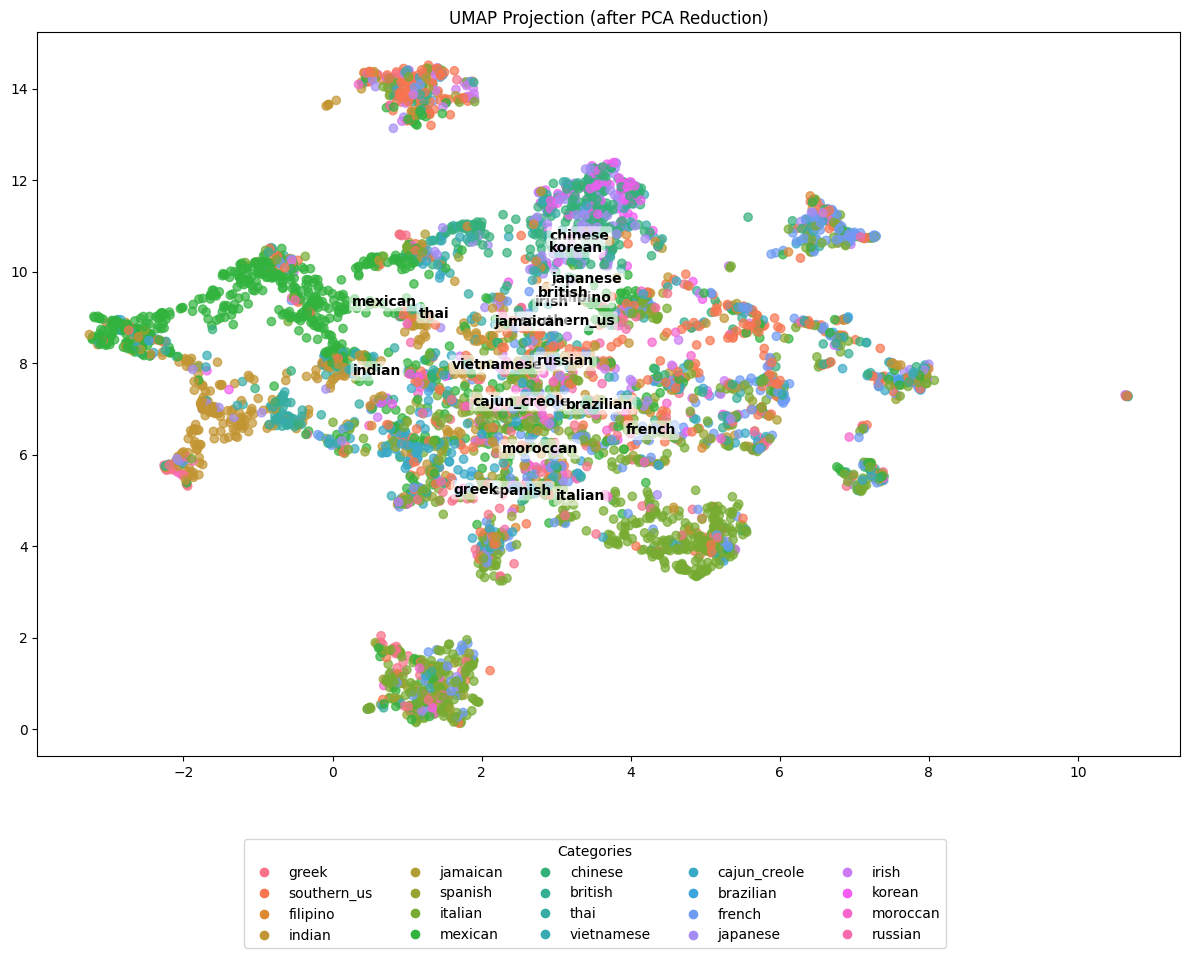

In [260]:
# Create a figure
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter points
scatter_umap = ax.scatter(umap_reduction[:, 0], umap_reduction[:, 1], c=colors, alpha=0.7)
ax.set_title('UMAP Projection (after PCA Reduction)')

# Label each cuisine once at its cluster center
for cuisine in random_subset['cuisine'].unique():
    # Find points for this cuisine
    indices = random_subset[random_subset['cuisine'] == cuisine].index
    x_mean = umap_reduction[indices, 0].mean()
    y_mean = umap_reduction[indices, 1].mean()

    ax.text(x_mean, y_mean + np.random.normal(0, 0.5), cuisine, fontsize=10, weight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

# Create legend handles using custom color dictionary
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markersize=8,
        markerfacecolor=cuisine_color_dict[cuisine_map[i]],
        label=cuisine_map[i]
    )
    for i in np.unique(labels)
]

# Add legend
fig.legend(handles=legend_handles, title='Categories', loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=5)

plt.tight_layout()
plt.show()

The UMAP above is based on a random sample of 5,000 recipes. Before applying UMAP, we first reduced the feature space to 30 dimensions using PCA. The resulting map shows some groupings that make intuitive sense — for example, Chinese recipes appearing near Korean ones. But there are also some pairings that seem less expected, like Russian recipes showing up close to Japanese and Vietnamese ones. Overall, we might expect smoother transitions across the map, where geographically or culturally similar cuisines are positioned closer together.

# NMF

* topic extraction
* cuisine-topic relationship
* cuisine-cuisine similarity

In [261]:
# Set number of topics
n_topics = 10

# Create and fit NMF model
nmf_model = NMF(n_components=n_topics, random_state=42)
W = nmf_model.fit_transform(recipe_vec)  # Recipe-topic matrix
H = nmf_model.components_                # Topic-ingredient matrix

**TOPIC EXTRACTION**

In [262]:
# Get feature names (ingredient unigrams and bigrams)
feature_names = vectorizer.get_feature_names_out()

# Show top N ingredients per topic
top_n = 10  # Top 10 ingredients

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[-top_n:][::-1]  # Top ingredients
    top_ingredients = [feature_names[i] for i in top_indices]
    print(f"\nTopic {topic_idx}:")
    print(", ".join(top_ingredients))


Topic 0:
ground, black, dried, kosher, turmeric, powder, masala, vegetable, tomato, onion

Topic 1:
large, egg, yolks, unsalted, purpose, extract, whites, heavy, whipping, granulated

Topic 2:
shredded, tortillas, chilies, cheddar, sour, jalapeno, green, jack, monterey, breasts

Topic 3:
soy, sesame, starch, brown, boneless, skinless, vegetable, toasted, green, breasts

Topic 4:
fresh, chopped, onion, cloves, purple, olive, spray, peeled, cooking, chile

Topic 5:
red, bell, green, crushed, flakes, paste, tomato, dried, peppers, curry

Topic 6:
parmesan, grated, mozzarella, dried, italian, ricotta, olive, crumbs, lasagna, shredded

Topic 7:
baking, powder, purpose, soda, vegetable, unsalted, extract, meal, curry, granulated

Topic 8:
olive, extra, virgin, cloves, flat, leaf, sea, kosher, black, balsamic

Topic 9:
white, dry, onion, bay, grain, long, leaf, active, warm, purpose


**CUISINE-TOPIC RELATIONSHIP**

In [263]:
# For each recipe, pick the topic with the highest score
recipe_topics = np.argmax(W, axis=1)

# Add to DataFrame
recipe_data['main_topic'] = recipe_topics

print(recipe_data[['id', 'cuisine', 'main_topic']].head())

      id      cuisine  main_topic
0  10259        greek           4
1  25693  southern_us           0
2  20130     filipino           2
3  22213       indian           3
4  13162       indian           0


In [264]:
# Cross-tabulation
cuisine_topic_table = pd.crosstab(recipe_data['cuisine'], recipe_data['main_topic'])

# Normalize to get percentages per cuisine
cuisine_topic_normalized = cuisine_topic_table.div(cuisine_topic_table.sum(axis=1), axis=0)

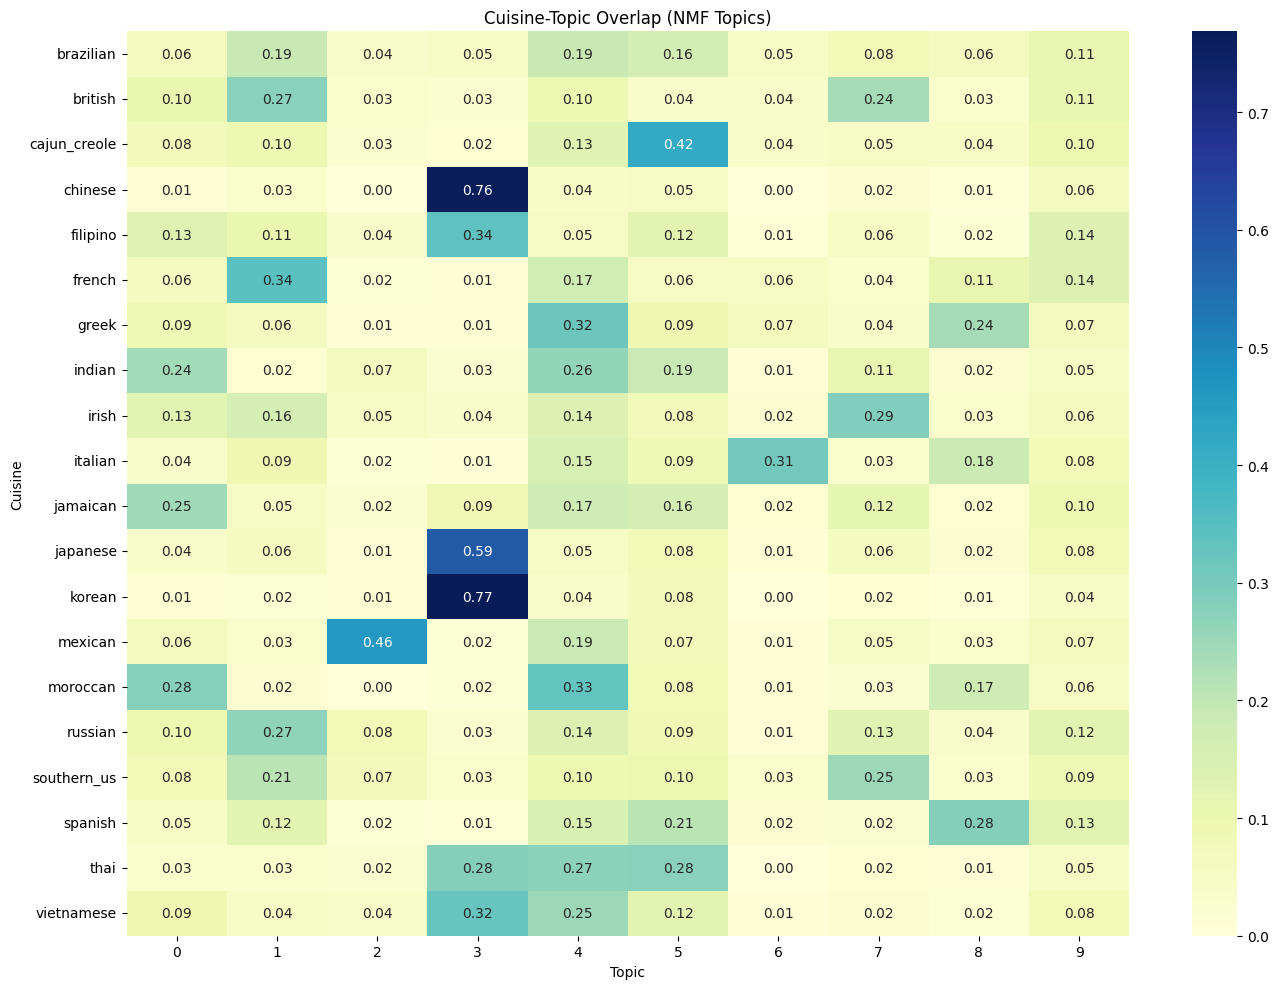

In [265]:
plt.figure(figsize=(14, 10))
sns.heatmap(cuisine_topic_normalized, cmap="YlGnBu", annot=True, fmt=".2f")

plt.title('Cuisine-Topic Overlap (NMF Topics)')
plt.xlabel('Topic')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

# Reccomender

* cuisine-cuisine similarity

**CUISINE-CUISINE SIMILARITY**

In [266]:
# Create a DataFrame for easier handling
W_df = pd.DataFrame(W)
W_df['cuisine'] = recipe_data['cuisine'].values

# Group by cuisine and compute the mean topic vector
cuisine_topic_matrix = W_df.groupby('cuisine').mean()

In [267]:
# Compute cosine similarity between cuisines
similarity_matrix = cosine_similarity(cuisine_topic_matrix)

# Convert to a DataFrame
similarity_df = pd.DataFrame(similarity_matrix, index=cuisine_topic_matrix.index, columns=cuisine_topic_matrix.index)

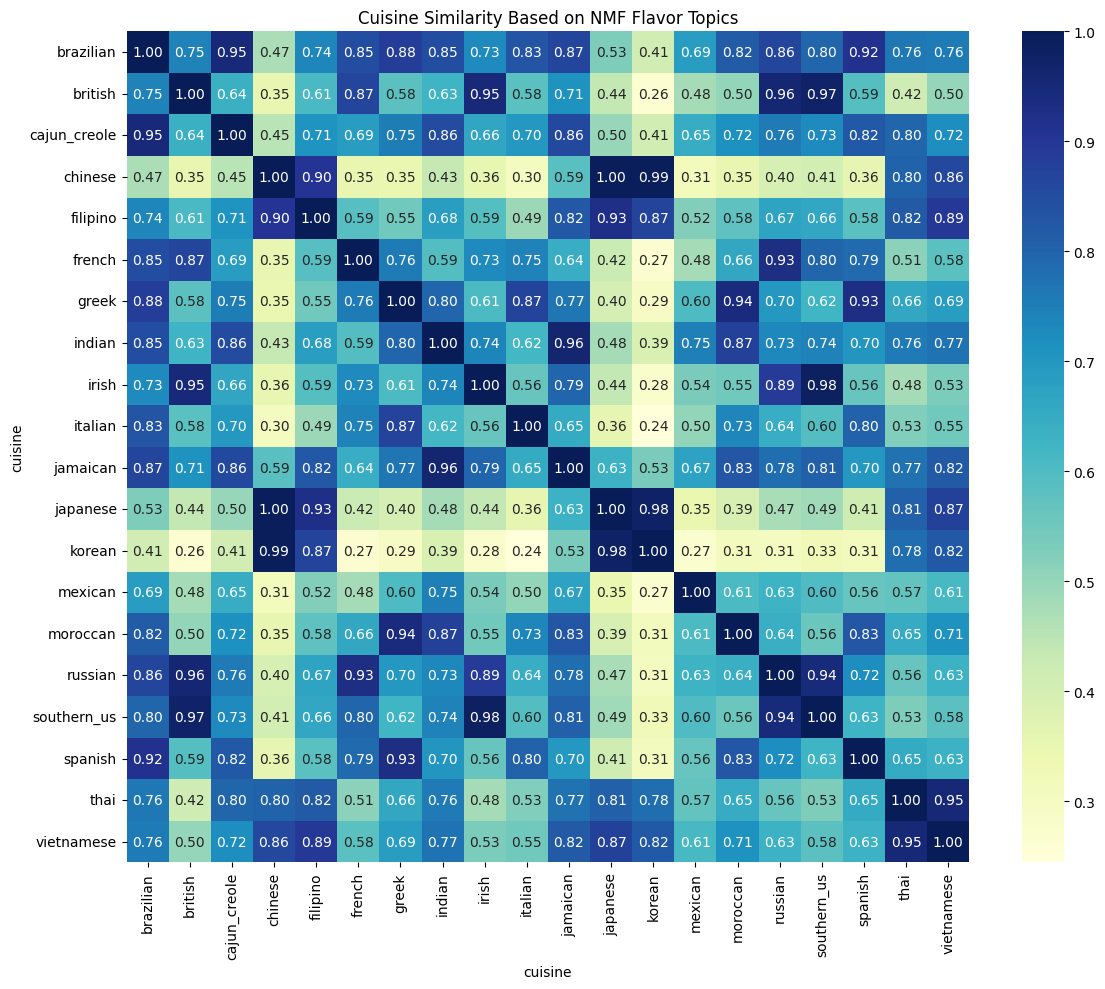

In [268]:
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_df, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Cuisine Similarity Based on NMF Flavor Topics")
plt.tight_layout()
plt.show()

In [269]:
# For each cuisine, find the most similar other cuisine
most_similar_cuisines = {}

for cuisine in similarity_df.index:
    # Exclude self-comparison by setting it to -1 temporarily
    similarity_series = similarity_df.loc[cuisine].copy()
    similarity_series[cuisine] = -1  # Ignore self
    most_similar = similarity_series.idxmax()  # Cuisine with highest similarity
    score = similarity_series.max()

    most_similar_cuisines[cuisine] = (most_similar, score)

# Convert to a readable DataFrame
similar_cuisines_df = pd.DataFrame(most_similar_cuisines).T
similar_cuisines_df.columns = ['most_similar_cuisine', 'similarity_score']
similar_cuisines_df = similar_cuisines_df.sort_values(by='similarity_score', ascending=False)

# Display
print(similar_cuisines_df)


             most_similar_cuisine similarity_score
chinese                  japanese         0.995313
japanese                  chinese         0.995313
korean                    chinese         0.991895
southern_us                 irish         0.983353
irish                 southern_us         0.983353
british               southern_us         0.972029
jamaican                   indian         0.960377
indian                   jamaican         0.960377
russian                   british         0.956785
thai                   vietnamese         0.951724
vietnamese                   thai         0.951724
cajun_creole            brazilian          0.94824
brazilian            cajun_creole          0.94824
greek                    moroccan         0.938385
moroccan                    greek         0.938385
french                    russian         0.931335
spanish                     greek         0.930733
filipino                 japanese          0.92546
italian                     gre

NMF uses the vectorized ingredient data to uncover underlying topics, or "flavor profiles" — groups of ingredients that tend to occur together. The number of flavor profiles can be adjusted to fine-tune how closely they connect to specific cuisines. A smaller number of topics results in broader flavor buckets with more ingredients per topic, while a larger number captures more of the subtle nuances between cuisines. To explore direct relationships between cuisines, we use a cosine similarity measure based on their topic distributions.

# Conclusion

Non-negative Matrix Factorization (NMF) does a solid job of revealing connections between cuisines based on recipe ingredients. As expected, Chinese, Japanese, and Korean cuisines share a similar flavor profile (topic 3) and don't have much overlap with the other nine topics. Thai cuisine, on the other hand, spreads across multiple topics — mainly flavor profiles 3, 4, and 5. For someone who enjoys Chinese food and wants to expand their palate, Thai could serve as a bridge to Cajun/Creole, which is heavily tied to flavor profile 5. It's a way for adventurous eaters to ease into new flavor combinations.

The cuisine-to-cuisine similarity scores also give us a fun way to either stick with what we love or branch out. For example, Spanish and Brazilian cuisines have high similarity scores, suggesting a shared flavor base — so if you like one, you'll probably enjoy the other. Meanwhile, Spanish and Korean have very low similarity scores, so trying the other could offer a completely different dining experience. One interesting observation: Italian and Mexican cuisines, despite being very popular, top out at similarity scores of 0.75 and 0.87, respectively — lower than the highest similarity scores seen between other cuisines. This could be a side effect of our dataset being heavily weighted toward Italian and Mexican recipes.

There are a few ways to improve model performance going forward. A more balanced dataset would help ensure that no single cuisine overwhelms the others. Refining the ingredient list — or using a custom food-specific vectorizer — could help filter out noise from common terms like “ground,” “black,” “chopped,” “shredded,” and “boneless,” which appear often in recipes but don't represent core ingredients. Future work could explore combining ingredient vectors with cooking methods or flavor compound data to create a more complete culinary similarity model.

# Citations

1. Kaggle What's Cooking Dataset
Kaggle. (2015). What's Cooking? [Data set]. Kaggle. https://www.kaggle.com/competitions/whats-cooking/data?select=test.json.zip

2. Scikit-learn TF-IDF Vectorizer Documentation
Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

3. UMAP Documentation
McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. https://umap-learn.readthedocs.io/en/latest/

